# EDA

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')

from utils.grafico_estacional import grafico_estacional

In [2]:
df = pd.read_csv('../datos/df_01.csv',
                parse_dates = ['fecha'],
                index_col = 'fecha')
df

,value
fecha,
2019-01-01 00:00:00,23216.0
2019-01-01 01:00:00,24947.0
2019-01-01 02:00:00,27655.0
2019-01-01 03:00:00,27676.0
2019-01-01 04:00:00,26853.0
...,...
2025-07-19 20:00:00,29380.0
2025-07-19 21:00:00,27763.0
2025-07-19 22:00:00,26659.0


### Posible estacionalidad

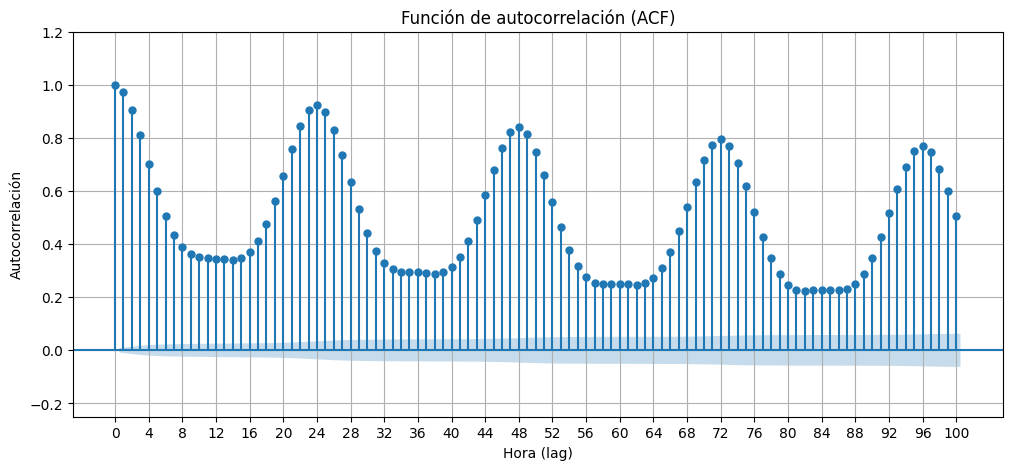

In [3]:
fig, ax = plt.subplots(1, figsize=(12,5))
fig = plot_acf(df, lags=100, ax=ax)

# Personalizar figura
xticks = np.arange(0,101,4)
ax.grid()
ax.set_ylim([-0.25, 1.2])
ax.set_xticks(xticks)
ax.set_xlabel('Hora (lag)')
ax.set_ylabel('Autocorrelación')
ax.set_title('Función de autocorrelación (ACF)');

* Los registros se toman cada hora, y se puede notar que la estacionalidad de la serie tiene presente una periodicidad de 24 horas.
* El patrón estacional se va debilitando con el tiempo, por lo que puede existir un componente no estacionario

### Gráficos estacionales

In [4]:
ts = df['value'].copy().to_frame()
ts['hora'] = ts.index.hour
ts['mes'] = ts.index.month
ts['año'] = ts.index.year
ts

,value,hora,mes,año
fecha,,,,
2019-01-01 00:00:00,23216.0,0,1,2019
2019-01-01 01:00:00,24947.0,1,1,2019
2019-01-01 02:00:00,27655.0,2,1,2019
2019-01-01 03:00:00,27676.0,3,1,2019
2019-01-01 04:00:00,26853.0,4,1,2019
...,...,...,...,...
2025-07-19 20:00:00,29380.0,20,7,2025
2025-07-19 21:00:00,27763.0,21,7,2025
2025-07-19 22:00:00,26659.0,22,7,2025


In [5]:
gb = ts.groupby(['mes', 'hora'])['value'].mean()
gb

mes  hora
1    0       23005.949309
     1       23881.216590
     2       25709.677419
     3       26854.216590
     4       26708.917051
                 ...     
12   19      24503.021505
     20      24113.188172
     21      23861.155914
     22      23837.854839
     23      24054.059140
Name: value, Length: 288, dtype: float64

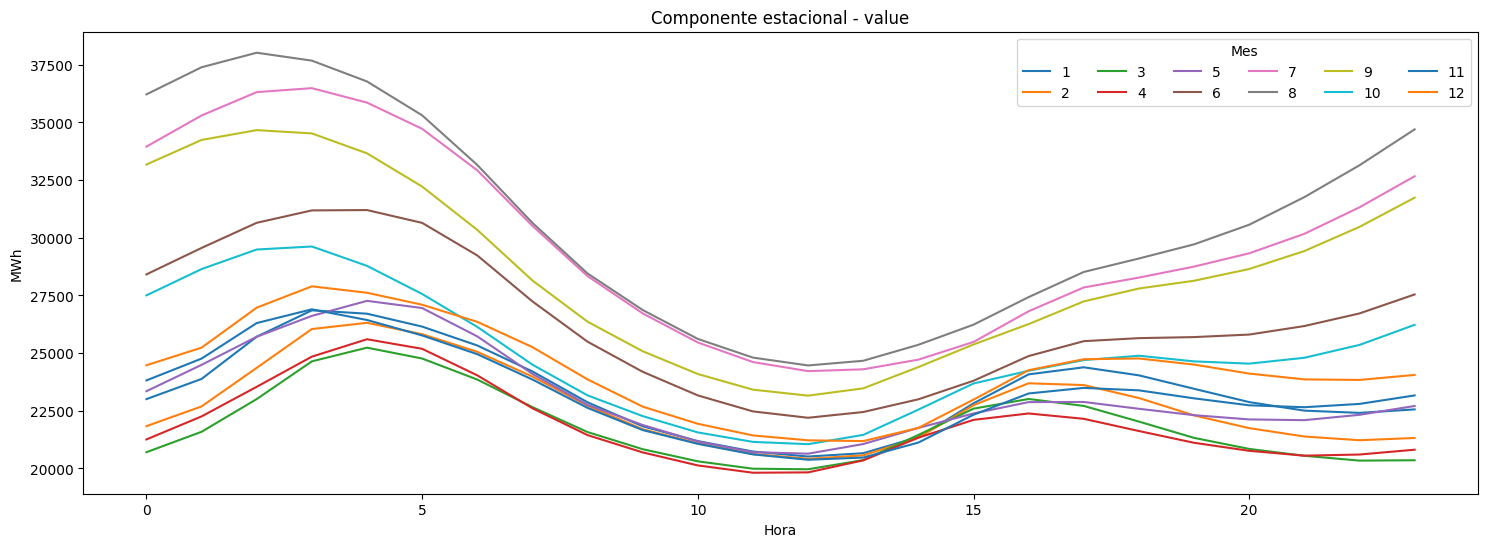

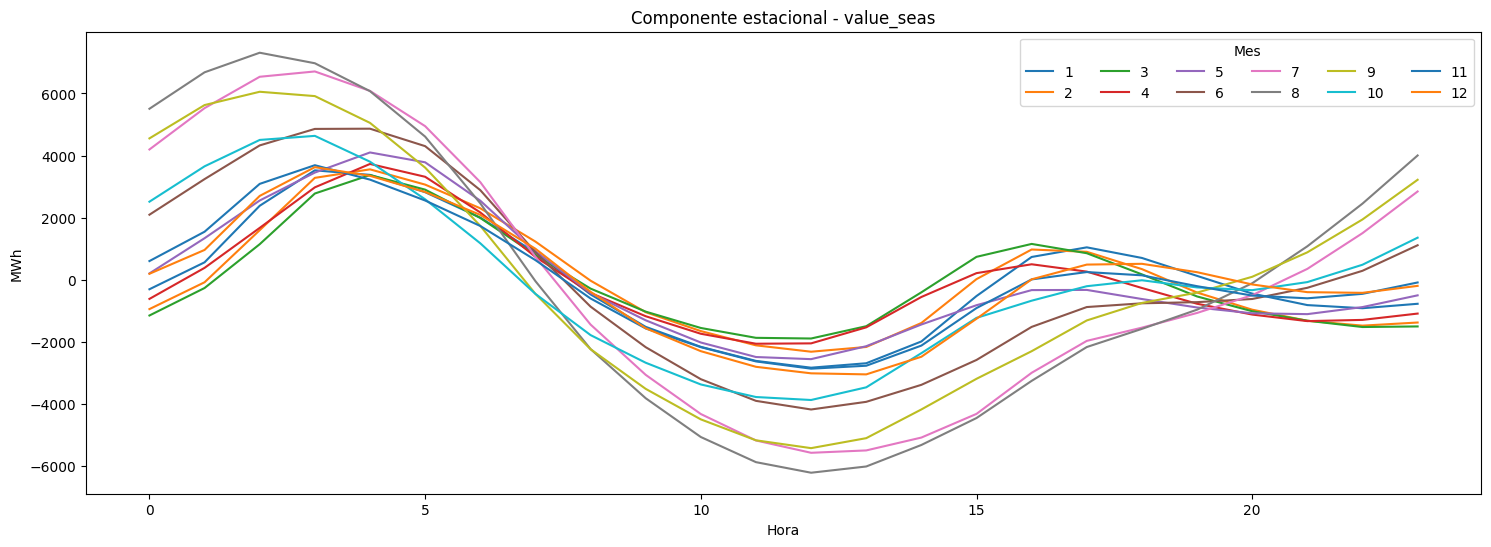

In [6]:
grafico_estacional(ts, 'value', 24, False)
grafico_estacional(ts, 'value', 24, True)